In [199]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import trapezoid, cumulative_trapezoid
from scipy.interpolate import interp1d
from scipy.optimize import fsolve

# Cinética de Procesos (Sesión 05)

<img src="figures/LogoCinvestav.png" style="height:100px" title="Cinvestav">

**CINVESTAV Unidad Saltillo**

**Programa de Maestría en Ciencias en Ingeniería Metalúrgica**

Dr. Edgar Ivan Castro Cedeño

Contacto:
[edgar.castro@cinvestav.mx](mailto:edgar.castro@cinvestav.mx)

# 6. Modelos de dos parámetros

## 6.1 CSTR con derivación y zona muerta

### 6.1.1 Esquematización

<center>

<img src="figures/images/cstr_bypass_dead.png" style="width:400px" title="CSTR">

***Figura 01. Modelo de un CSTR con derivación y zona muerta.*** 


</center>

**El modelo de reactor CSTR con derivación y zona muerta, es un modelo en régimen estacionario, que consta de los siguiente componentes:**

**Unión 1:**

- El flujo volumétrico de entrada, $\dot{Q}_0$, se descompone en el flujo efectivo en el reactor, $\dot{Q}_s$, y el flujo en la derivación $\dot{Q}_b$.

$$\dot{Q}_0 = \dot{Q}_s + \dot{Q}_b$$

- La concentración es igual a la concentración inicial, $C_{\mathrm{A}}^0$.

**Reactor:**

- El volumen total del reactor, $V$, se descompone en el volumen efectivo de reacción, $V_S$, y el volumen de la zona muerta $V_d$.
$$V = V_s + V_d$$

- En el volumen efectivo de reacción, $V_S$, la cinética ocurre de acuerdo con la ecuación de diseño de un CSTR ideal.

    - El tiempo espacial del reactor se calcula a partir del volumen y del flujo efectivos, $\tau_s = V_s / \dot{Q}_s$.

    - La concentración a la salida del reactor, se denota mediante la variable $C_{\mathrm{A}}^S$.


$$\dot{Q}_s C_{\mathrm{A}}^0 - \dot{Q}_s  C_{\mathrm{A}}^s + r_{\mathrm{A}} V_{s} = 0$$

$$C_{\mathrm{A}}^0 - C_{\mathrm{A}}^s + r_{\mathrm{A}} \tau_{s} = 0$$

- En el volumen de la zona muerta, $V_d$, no ocurre ninguna reacción.





**Unión 2:**

- El flujo volumétrico a la salida, $\dot{Q_0}$, está constituido por el efluente del reactor, $\dot{Q_S}$ y el flujo en la derivación, $\dot{Q_b}$.

$$\dot{Q}_0 = \dot{Q}_s + \dot{Q}_b$$

- La concentración a la salida del reactor se calcula a partir del balance de materia en la unión:


$$\underbrace{C_{\mathrm{A}}^0 \dot{Q}_b + C_{\mathrm{A}}^S \dot{Q}_S}_{\text{entradas}} = \underbrace{C_{\mathrm{A}} \dot{Q}_0}_{\text{salidas}}$$

$$C_{\mathrm{A}} = \frac{C_{\mathrm{A}}^0 \dot{Q}_b + C_{\mathrm{A}}^S \dot{Q}_S}{\dot{Q}_0}$$

### 6.1.2 Parametrización

Este modelo consta de dos parámetros ajustables:

- La fracción de volumen efectivo del reactor
$$\alpha = \frac{V_s}{V}$$

- La fracción del flujo volumétrico que pasa por la derivación:

$$\beta = \frac{\dot{Q}_b}{\dot{Q}_0}$$

La concentración a la salida del reactor se puede reescribir en términos de $\beta$:

$$C_{\mathrm{A}} = \frac{C_{\mathrm{A}}^0 \dot{Q}_b + C_{\mathrm{A}}^S \dot{Q}_S}{\dot{Q}_0}$$

$$C_{\mathrm{A}} = \beta C_{\mathrm{A}}^0 + \left(1 - \beta \right) C_{\mathrm{A}}^s$$

In [200]:
########################################### Modelo CSTR-bypass-deadzone.

### Ecuacion CSTR a optimizar (encontrar raiz)
def cstrOptFun(cA, cA0, r_A, tau):
    return    cA0 - cA + tau*r_A(cA)
    
### Resolvedor
def cstr_bypass_dead(cA0, V, Q, r_A, alp, bet):
    tau = V/Q # tiempo caracteristico del CSTR global
    # calculo de volumenes y flujos    
    Vs, Vd = alp*V, (1-alp)*V # volumenes de zona de reaccion y zona muerta.
    Qs, Qb = (1-bet)*Q, bet*Q # flujos volumetricos zona reaccion y bypass.
    
    # casos límite: beta-->1, alpha-->0
    if ((bet >= 1.0) or (alp<=0)):    
        return cA0
    # si existe volumen de reaccion y parte del flujo va hacia el CSTR
    taus = Vs/Qs
    cAs = fsolve(cstrOptFun, x0=cA0, args=(cA0, r_A, taus))[0]
    return bet*cA0 + (1-bet)*cAs

In [201]:
### Condiciones del reactor
V = 15 # m3, volumen total del reactor
Q = 1 # m3/min, flujo volumétrico total en el reactor.
cA0 = 1.0 # mol/m3, concentracion inicial de A
k = 0.307 #C^(n-1)/min
r_A = lambda cA: -k*cA

# Parametros de entrada
alp = 0.95                    # Vs/V fraccion de volumen reactivo
bet = 0.5                  # Qb/Q0 fraccion de volumen derivado (bypass)

cA = cstr_bypass_dead(cA0, V, Q, r_A, alp, bet)
print(f"cA: {cA:.4f}")
print(f"X : {1-cA/cA0:.4f}")

cA: 0.5513
X : 0.4487


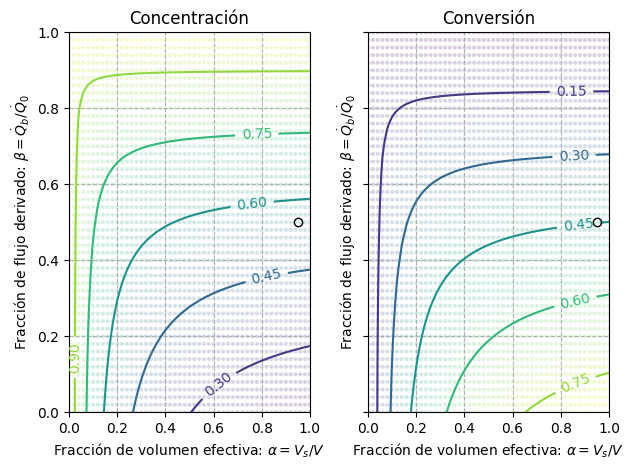

0.8215878679750223


In [202]:
### Condiciones del reactor
V = 15 # m3
Q = 1 # m3/min
cA0 = 1
k = 0.307 # 1/min
r_A = lambda cA: -k*cA

# mapeo
alphas = np.linspace(0, 1, 51)
betas = np.linspace(0, 1, 51)
data = []
for alpha in alphas:
    for beta in betas:
        cA = cstr_bypass_dead(cA0, V, Q, r_A, alpha, beta)
        data.append([alpha, beta, cA, 1-cA/cA0])
data = np.array(data)

# graficos
fig, (ax0, ax1) = plt.subplots(ncols=2, sharex=True, sharey=True)
# concentraciones
cs = ax0.tricontour(data[:,0], data[:,1], data[:, 2])
ax0.scatter(data[:,0], data[:,1], c=data[:,2], marker='.', edgecolor='None', alpha=0.2)
ax0.plot(alp, bet, ls='', marker='o', c="k", mfc="None")
ax0.clabel(cs)
# conversiones
cs = ax1.tricontour(data[:,0], data[:,1], data[:, 3])
ax1.scatter(data[:,0], data[:,1], c=data[:,3], marker='.', edgecolor='None', alpha=0.2)
ax1.plot(alp, bet, ls='', marker='o', c="k", mfc="None")
ax1.clabel(cs)
for ax in (ax0, ax1):
    ax.set_xlabel(r"Fracción de volumen efectiva: $\alpha = {V_s}/{V}$")
    ax.set_ylabel(r"Fracción de flujo derivado: $\beta = {\dot{Q}_b}/{\dot{Q}_0}$")
    ax.grid(ls='--')
ax0.set_title("Concentración")
ax1.set_title("Conversión")
fig.tight_layout()
plt.show()
print(1 - cstr_bypass_dead(cA0, V, Q, r_A, 1.0, 0.0)/cA0)

### 6.1.3 Determinación de parámetros a partir de curva RTD

El balance de masa transitorio para un experimento de inyección continua de un trazador inerte en el reactor CSTR con derivación y zona muerta se escribe:

$$\underbrace{V_s\frac{dC_{\mathrm{T}}}{dt}}_{\text{acumulación}}= \underbrace{\dot{Q}_s C_{\mathrm{T_0}}}_{\text{entradas}} - \underbrace{\dot{Q}_s C_{\mathrm{T_s}}}_{\text{salidas}}$$

La condiciones en la entrada del reactor son:

$$C_{\mathrm{T}} = \left\{ \begin{matrix} 0 \forall t< 0 \\ C_{\mathrm{T_0}} \forall t \ge 0 \end{matrix} \right.$$

Y el balance de materia en la unión 2 (donde se juntan el flujo derivado y el flujo de salida del CSTR) se escribe:

$$C_{\mathrm{T}} = \frac{C_{\mathrm{T_0}} \dot{Q}_b + C_{\mathrm{T_S}} \dot{Q}_S}{\dot{Q}_0}$$

Recordando que:

$$V_{s} = \alpha V$$

$$\dot{Q}_b = \beta \dot{Q}$$

$$\tau = \frac{V}{\dot{Q}_0}$$

Integrando el balance de masa, y sustituyendo en términos de $\alpha$ y $\beta$ se obtiene:

$$\frac{C_{\mathrm{T}}}{C_{\mathrm{T_0}}} = 1 - \exp \left[-\frac{1-\beta}{\alpha} \left(\frac{t}{\tau}\right)  \right]$$

Rearreglando la ecuación de tal forma que el perfil de concentración sea una función explícita de los parámetros $\alpha$, $\beta$, y el tiempo ($t$), se tiene:


$$\ln \frac{C_{\mathrm{T_0}}}{C_{\mathrm{T_0}} - C_{\mathrm{T}}} = \ln \frac{1}{1-\beta} + \left(\frac{1-\beta}{\alpha}\right) \frac{t}{\tau}$$

Al graficar $\ln \frac{C_{\mathrm{T_0}}}{C_{\mathrm{T_0}}}$ como función de $t$, si el modelo es correcto, los datos deberían de aproximarse a una línea recta con pendiente $M=\left(\frac{1-\beta}{\alpha}\right)$, e intercepto $B=\left(\ln \frac{1}{1-\beta}\right)$.

$$\beta = 1 - \exp \left(-B \right)$$

$$\alpha = \frac{1-\beta}{\tau M}$$

### 6.1.4 Ejemplos

#### 6.1.4.1

    Fogler, Ex. 18-2

La reacción elemental:

$$\mathrm{A + B \rightarrow C+D}$$

se realiza en un CSTR para el que se sospecha que existen regiones con derivación y estagnantes. Se realiza un experimento de inyección de trazador continuo para el cuál se reportan resultados debajo. El volumen del reactor es de $1.0$ $\mathrm{m^3}$ y el flujo volumétrico en el reactor es de $0.1$ $\mathrm{m^3.min^{-1}}$. 

La constante de reacción es $0.28$ $\mathrm{m^3.mol^{-1}.min^{-1}}$. El reactor se alimenta con flujos equimolares de $\mathrm{A}$ y $\mathrm{B}$, con una concentración a la entrada de $\mathrm{A}$ de $2.0$ $\mathrm{kmol.m^{-3}}$, al igual que la concentración del trazador.

Calcule la conversión esperada en el reactor.

In [203]:
cT0 = 2000 # mg/dm3
cT = np.array([1000, 1333, 1500, 1666, 1750, 1800]) # mg/dm3
t  = np.array([   4,    8,   10,   14,   16,   18]) # min

V = 1.0 # m3
Q0 = 0.1 # m3/min
tau = V/Q0

cA0 = 2 # kmol/m3
r_A = lambda cA: -0.28*cA**(2) #equimolar feed of A and B

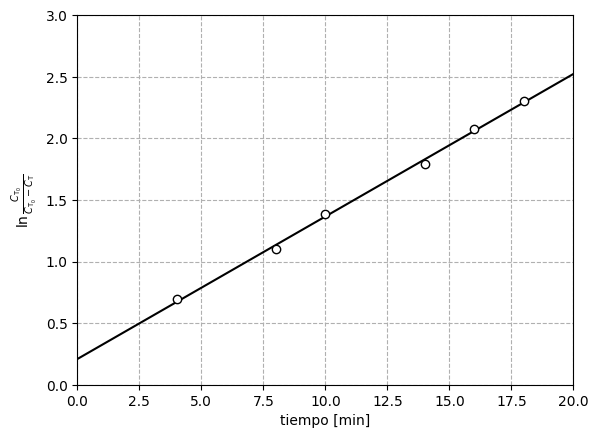

alpha=0.7017, beta=0.1882
Conversión (modelo): 0.5172
Conversión (ideal): 0.6574


In [204]:
## trazar gráfico
fig, ax = plt.subplots()
x, y = t, np.log(cT0/(cT0-cT))
# ajuste a ecuación de 1er grado
cx = np.polyfit(x, y, deg=1)
tt = np.linspace(0, 20, 10)
ax.plot(tt, np.poly1d(cx)(tt), color='k')
ax.plot(x, y, ls='', marker='o', color='k', mfc="w")
ax.set_ylim(0, 3)
ax.set_xlim(0, 20)
ax.set_xlabel("tiempo [min]")
ax.set_ylabel(r"$\ln \frac{C_{\mathrm{T_0}}}{C_{\mathrm{T_0}} - C_{\mathrm{T}}}$")
ax.grid(ls='--')
plt.show()

# Calculo de alpha y beta
slope, intercept = cx[0], cx[1]
bet = 1 - np.exp(-intercept)
alp = (1-bet)/(tau*slope)
# calculo de alpha
print(f"alpha={alp:.4f}, beta={bet:.4f}")

# Calculo de la conversión (modelo)
cA = cstr_bypass_dead(cA0, V, Q0, r_A, alp, bet)
X = 1 - cA/cA0
print(f"Conversión (modelo): {X:.4f}")

# Calculo de conversion (CSTR ideal)
cA = cstr_bypass_dead(cA0, V, Q0, r_A, 1.0, 0.0)
X = 1 - cA/cA0
print(f"Conversión (ideal): {X:.4f}")


#### 6.1.4.2

    Fogler, Ex. 18.3

In [205]:
t  = np.array([0.0, 2.0, 40, 60, 80, 120, 160, 200, 240]) # min
cT = np.array([2000, 1050, 520, 280, 160, 61, 29, 16.4, 10.0]) # mg/dm3


V = 1.0 # m3
Q0 = 0.1 # m3/min
tau = V/Q0

cA0 = 2 # kmol/m3
r_A = lambda cA: -0.28*cA**(2) #equimolar feed of A and B

# Curva C(t)
Ci = interp1d(t, cT, kind='linear') # linear
# Curva E(t)
Ei = interp1d(t, Ci(t)/trapezoid(Ci(t),t)) # linear
# Curva F(t)
Fi = interp1d(t, cumulative_trapezoid(Ei(t), t, initial=0)) # linear

cT0 = cT[0]
cT = cT0 * Fi(t)[1:-1]
print(cT)


[ 115.2334895  1242.25479825 1544.50657398 1710.74505063 1877.73915672
 1945.74580626 1980.0513828 ]


In [206]:
np.log(cT0/(cT0-cT))

array([0.05934323, 0.97055528, 1.47952118, 1.93359398, 2.79474564,
       3.60722217, 4.60774263])

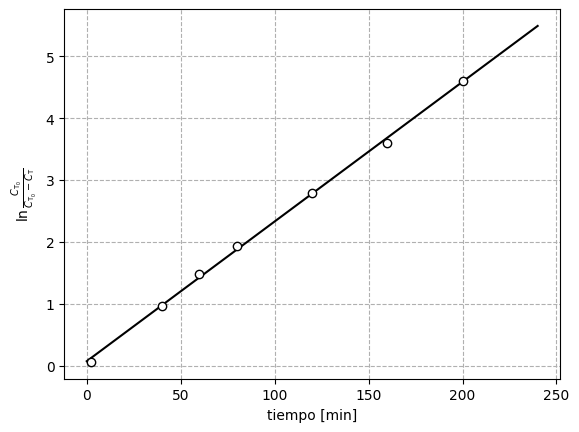

alpha=4.1229, beta=0.0686
Conversión (modelo): 0.9268
Conversión (ideal): 0.9787


In [212]:
## trazar gráfico
fig, ax = plt.subplots()
x, y = t[1:-1], np.log(cT0/(cT0-cT))
# ajuste a ecuación de 1er grado
cx = np.polyfit(x, y, deg=1)
tt = np.linspace(0, 240, 10)
ax.plot(tt, np.poly1d(cx)(tt), color='k')
ax.plot(x, y, ls='', marker='o', color='k', mfc="w")
#ax.set_ylim(0, 3)
#ax.set_xlim(0, 20)
ax.set_xlabel("tiempo [min]")
ax.set_ylabel(r"$\ln \frac{C_{\mathrm{T_0}}}{C_{\mathrm{T_0}} - C_{\mathrm{T}}}$")
ax.grid(ls='--')
plt.show()

# Calculo de alpha y beta
slope, intercept = cx[0], cx[1]
bet = 1 - np.exp(-intercept)
alp = (1-bet)/(tau*slope)
# calculo de alpha
print(f"alpha={alp:.4f}, beta={bet:.4f}")

# Calculo de la conversión (modelo)
cA = cstr_bypass_dead(cA0, V, Q0, r_A, alp, bet)
X = 1 - cA/cA0
print(f"Conversión (modelo): {X:.4f}")

# Calculo de conversion (CSTR ideal)
cA = cstr_bypass_dead(cA0, V, Q0, r_A, 1.0, 0.0)
X = 1 - cA/cA0
print(f"Conversión (ideal): {X:.4f}")



<div class="alert alert-danger">

<center>

**¿Qué se ve raro en el resultado?**

</center>


</div>

## 6.2 CSTR modelado como 2 CSTR con intercambio

### 6.2.1 Esquematización

<center>

<img src="figures/images/cstr_two_cstr_interchange.png" style="width:400px" title="CSTR">

***Figura 01. Modelo de un CSTR como dos CSTR con intercambio.*** 


</center>

**El modelo de reactor CSTR como dos CSTR con intercambio, es un modelo en régimen estacionario, que consta de los siguiente componentes:**

**Dos regiones:**



**Hipótesis:**

- El reactor está compuesto por dos regiones, que se pueden modelar como CSTR ideales:
    - Región uno: zona de alta agitación.
    - Región dos: zona con menor agitación.

- Hay una transferencia de masa considerable entra las dos regiones:
    - La entrada y salida global del reactor solo "ven" a la región uno.
    - Las entradas y salidas de la región dos están interconectadas a la región uno.


### 6.2.2 Parametrización

Este modelo consta de dos parámetros ajustables:

- La fracción de volumen ocupada por la zona de alta agitación:

$$\alpha = \frac{V_1}{V}$$

- La fracción del flujo volumétrico que se intercambia entre las dos zonas:

$$\beta = \frac{\dot{Q}_1}{\dot{Q}_0}$$

La concentración a la salida del reactor se puede reescribir en términos de $\beta$:

$$C_{\mathrm{A}} = \frac{C_{\mathrm{A}}^0 \dot{Q}_b + C_{\mathrm{A}}^S \dot{Q}_S}{\dot{Q}_0}$$

$$C_{\mathrm{A}} = \beta C_{\mathrm{A}}^0 + \left(1 - \beta \right) C_{\mathrm{A}}^s$$

In [208]:
########################################### Modelo CSTR-2_Interchange

### Ecuacion CSTR a optimizar (encontrar raiz)
def cstrTwoOptFun(cA, cA0, V, Q, r_A, alp, bet):
    cA1, cA2 = cA
    V1, V2 = alp*V, (1-alp)*V
    Q1 = beta*Q0
    system = np.array([
        cA0*Q0 + cA2*Q1 - (Q0+Q1)*cA1 + r_A(cA1)*V1,
        cA1*Q1 - cA2*Q1 + r_A(cA2)*V2
    ])
    return    system
    
### Resolvedor
def cstr_2_inter(cA0, V, Q, r_A, alp, bet):
    tau = V/Q # tiempo caracteristico del CSTR global
    # casos límite: alpha-->0 (CSTR ideal)
    if ((alp >= 1.0)):
        return [fsolve(cstrOptFun, x0=cA0, args=(cA0, r_A, tau))[0], 0.0]
    ### beta --> 0 (la zona 2 es zona muerta)
    if ((bet <= 0.0)):
        tau = (alp*V) / Q
        return [fsolve(cstrOptFun, x0=cA0, args=(cA0, r_A, tau))[0], 0.0]
    # resto de los casos
    cAs = fsolve(cstrTwoOptFun, x0=[cA0, cA0], args=(cA0, V, Q, r_A, alp, bet))
    return cAs

In [209]:
### Condiciones del reactor
V = 15 # m3, volumen total del reactor
Q = 1 # m3/min, flujo volumétrico total en el reactor.
cA0 = 1.0 # mol/m3, concentracion inicial de A
k = 0.307 #C^(n-1)/min
r_A = lambda cA: -k*cA

# Parametros de entrada
alp = 0.2                 # V1/V fraccion de volumen en la zona con alta agitación
bet = 0.1                  # Q1/Q0 fraccion de flujo intercambiado entre las dos zonas

cA = cstr_2_inter(cA0, V, Q, r_A, alp, bet)
cA = cA[0]
print(f"cA: {cA:.4f}")
print(f"X : {1-cA/cA0:.4f}")

cA: 0.0894
X : 0.9106


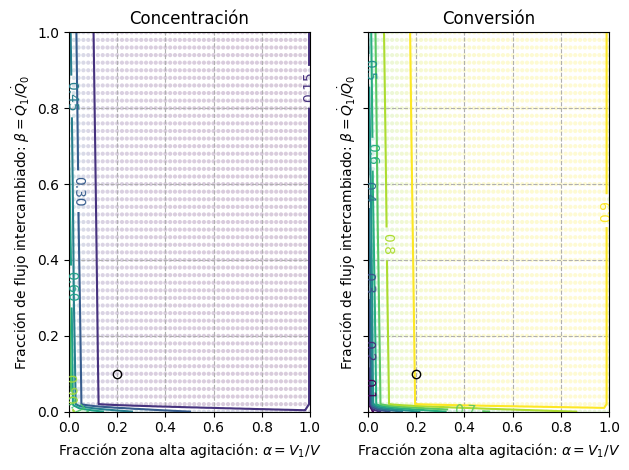

In [210]:
### Condiciones del reactor
V = 15 # m3
Q = 1 # m3/min
cA0 = 1
k = 0.307 # 1/min
r_A = lambda cA: -k*cA

# mapeo
alphas = np.linspace(0, 1, 51)
betas = np.linspace(0, 1, 51)
data = []
for alpha in alphas:
    for beta in betas:
        cA = cstr_2_inter(cA0, V, Q, r_A, alpha, beta)[0]
        data.append([alpha, beta, cA, 1-cA/cA0])
data = np.array(data)

fig, (ax0, ax1) = plt.subplots(ncols=2, sharex=True, sharey=True)
# concentraciones
cs = ax0.tricontour(data[:,0], data[:,1], data[:, 2])
ax0.scatter(data[:,0], data[:,1], c=data[:,2], marker='.', edgecolor='None', alpha=0.2)
ax0.plot(alp, bet, ls='', marker='o', c="k", mfc="None")
ax0.clabel(cs)
# conversiones
cs = ax1.tricontour(data[:,0], data[:,1], data[:, 3], levels=[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9])
ax1.scatter(data[:,0], data[:,1], c=data[:,3], marker='.', edgecolor='None', alpha=0.2)
ax1.plot(alp, bet, ls='', marker='o', c="k", mfc="None")
ax1.clabel(cs)
for ax in (ax0, ax1):
    ax.set_xlabel(r"Fracción zona alta agitación: $\alpha = {V_1}/{V}$")
    ax.set_ylabel(r"Fracción de flujo intercambiado: $\beta = {\dot{Q}_1}/{\dot{Q}_0}$")
    ax.grid(ls='--')
ax0.set_title("Concentración")
ax1.set_title("Conversión")
fig.tight_layout()
plt.show()

### 6.2.3 Determinación de parámetros a partir de curva RTD

El balance de masa transitorio para un experimento de inyección en pulso de un trazador inerte en dos CSTR interconectados se escribe:

- Reactor 1:

$$\underbrace{V_1 \frac{dC_{T_1}}{dt}}_{\text{acumulación}} = \underbrace{\dot{Q}_1 C_{T_2}}_{\text{entradas}} - \underbrace{\left(\dot{Q}_0 C_{T_1} + \dot{Q}_1 C_{T_1} \right)}_{\text{salidas}}$$

- Reactor 2:

$$\underbrace{V_2 \frac{dC_{T_2}}{dt}}_{\text{acumulación}} = \underbrace{\dot{Q}_1 C_{T_1}}_{\text{entradas}} - \underbrace{\dot{Q}_1 C_{T_2}}_{\text{salidas}}$$




La condiciones iniciales en los reactores son:

- Reactor 1:

$$C_{T_{10}} = \frac{N_{T0}}{V_1}$$

- Reactor 2:

$$C_{T_{20}} = 0.0$$


Recordando que:

$$V_{1} = \alpha V$$

$$\dot{Q}_1 = \beta \dot{Q}_0$$

$$\tau = \frac{V}{\dot{Q}_0}$$


Se obtiene un sistema de ecuaciones diferenciales acopladas:

$$\tau \alpha \frac{dC_{T_1}}{dt} = \beta C_{T_2} - \left(1-\beta\right) C_{T_1}$$

$$\tau \left(1-\alpha\right) \frac{dC_{T_2}}{dt} = \beta C_{T_1} - \beta C_{T_2}$$